<a href="https://colab.research.google.com/github/Farhan-ANWAR0611/Distributed-Machine-Learning/blob/main/Data_Analysis_and_Management_using_Hadoop_%26_Hive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis and Management using Hadoop & Hive**

##### **Name**          - Nischay Verma

## **GitHub Link** :
https://github.com/Nischay-verma/Capstone-2-ML-Engineering-Financial-Forecasting-Frontier-Distributed-ML

## **Drive Link** :
https://drive.google.com/drive/folders/1lv1MivgxVPQHjG78N2A_v2d2VKHM4Kvg?usp=sharing

#Hadoop

In [34]:
#Load the bank.csv dataset into your environment and inspect the first few rows.
import pandas as pd

df = pd.read_csv("/content/bank (1).csv", sep=',', header=0)
df.columns = df.columns.str.strip()  # Remove any extra spaces
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


This step successfully loads the bank dataset into memory as a DataFrame using Pandas.
We also inspected the first few records to confirm that data was loaded correctly.

In [35]:
print(df.columns)



Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


####Write a MapReduce program in Python that calculates the average account balance for each job type.

In [36]:
# Conceptual MapReduce program for calculating average account balance by job type

# Mapper Function
def mapper(record):
    # Assuming 'record' is a dictionary or an object with 'job' and 'balance' attributes
    # In a real MapReduce, this would parse a line from the input file
    job_type = record['job']
    balance = record['balance']
    # Emit (key, value) pairs: (job_type, balance)
    yield job_type, balance

# Reducer Function
def reducer(job_type, balances):
    # 'balances' will be an iterable of all balances for a given job_type
    total_balance = sum(balances)
    count = len(balances)
    average_balance = total_balance / count if count > 0 else 0
    # Emit (key, value) pair: (job_type, average_balance)
    yield job_type, average_balance

# --- Simulation of MapReduce execution using the existing 'df' Pandas DataFrame ---

# 1. Map Phase
# Collect all key-value pairs emitted by mappers
mapped_data = []
for index, row in df.iterrows():
    # Simulate mapper for each row in the DataFrame
    for key, value in mapper(row.to_dict()): # Convert row to dict for easy access
        mapped_data.append((key, value))

# 2. Shuffle and Sort Phase (simulated)
# Group balances by job type
shuffled_data = {}
for job_type, balance in mapped_data:
    if job_type not in shuffled_data:
        shuffled_data[job_type] = []
    shuffled_data[job_type].append(balance)

# 3. Reduce Phase
reduced_results = []
for job_type, balances in shuffled_data.items():
    # Simulate reducer for each job type
    for key, value in reducer(job_type, balances):
        reduced_results.append((key, value))

# Sort results for better readability
reduced_results_sorted = sorted(reduced_results, key=lambda x: x[1], reverse=True)

# Display the results
print("Average Account Balance by Job Type (simulated MapReduce):")
for job_type, avg_balance in reduced_results_sorted:
    print(f"Job: {job_type:<15} Average Balance: {avg_balance:.2f}")


Average Account Balance by Job Type (simulated MapReduce):
Job: retired         Average Balance: 2319.19
Job: housemaid       Average Balance: 2083.80
Job: management      Average Balance: 1766.93
Job: entrepreneur    Average Balance: 1645.12
Job: student         Average Balance: 1543.82
Job: unknown         Average Balance: 1501.71
Job: self-employed   Average Balance: 1392.41
Job: technician      Average Balance: 1331.00
Job: admin.          Average Balance: 1226.74
Job: services        Average Balance: 1103.96
Job: unemployed      Average Balance: 1089.42
Job: blue-collar     Average Balance: 1085.16


This output represents the average account balance for clients across different job categories. It shows that retired individuals hold the highest average balance, while blue-collar workers have the lowest. This indicates clear variation in financial behavior across occupations, helping identify which groups maintain higher or lower savings levels.

#### Write another MapReduce program that counts the number of individuals with and without a housing loan in each education category.

In [37]:
# Conceptual MapReduce program to count individuals with/without housing loan by education

# Mapper Function
def housing_loan_mapper(record):
    education = record['education']
    housing_loan_status = record['housing'] # 'yes' or 'no'
    # Emit (key, value) pairs: ((education, housing_loan_status), 1)
    yield (education, housing_loan_status), 1

# Reducer Function
def housing_loan_reducer(key, counts):
    # 'counts' will be an iterable of '1's for a given key
    total_count = sum(counts)
    # Emit (key, value) pair: ((education, housing_loan_status), total_count)
    yield key, total_count

# --- Simulation of MapReduce execution using the existing 'df' Pandas DataFrame ---

# 1. Map Phase
mapped_housing_data = []
for index, row in df.iterrows():
    for key, value in housing_loan_mapper(row.to_dict()):
        mapped_housing_data.append((key, value))

# 2. Shuffle and Sort Phase (simulated)
shuffled_housing_data = {}
for (education, housing_loan_status), count in mapped_housing_data:
    if (education, housing_loan_status) not in shuffled_housing_data:
        shuffled_housing_data[(education, housing_loan_status)] = []
    shuffled_housing_data[(education, housing_loan_status)].append(count)

# 3. Reduce Phase
reduced_housing_results = []
for key, counts in shuffled_housing_data.items():
    for result_key, result_value in housing_loan_reducer(key, counts):
        reduced_housing_results.append((result_key, result_value))

# Sort results for better readability
reduced_housing_results_sorted = sorted(reduced_housing_results, key=lambda x: (x[0][0], x[0][1]))

# Display the results
print("Number of Individuals with/without Housing Loan by Education Category (simulated MapReduce):")
for (education, housing_loan_status), count in reduced_housing_results_sorted:
    print(f"Education: {education:<10} Housing Loan: {housing_loan_status:<5} Count: {count}")


Number of Individuals with/without Housing Loan by Education Category (simulated MapReduce):
Education: primary    Housing Loan: no    Count: 295
Education: primary    Housing Loan: yes   Count: 383
Education: secondary  Housing Loan: no    Count: 876
Education: secondary  Housing Loan: yes   Count: 1430
Education: tertiary   Housing Loan: no    Count: 687
Education: tertiary   Housing Loan: yes   Count: 663
Education: unknown    Housing Loan: no    Count: 104
Education: unknown    Housing Loan: yes   Count: 83


####Perform a MapReduce job to determine the number of clients contacted in each month and their subscription status to term deposits ('y' column).

In [38]:
# Conceptual MapReduce program to count clients contacted monthly by subscription status

# Mapper Function
def monthly_contact_mapper(record):
    month = record['month']
    subscription_status = record['y'] # 'yes' or 'no'
    # Emit (key, value) pairs: ((month, subscription_status), 1)
    yield (month, subscription_status), 1

# Reducer Function
def monthly_contact_reducer(key, counts):
    # 'counts' will be an iterable of '1's for a given key
    total_count = sum(counts)
    # Emit (key, value) pair: ((month, subscription_status), total_count)
    yield key, total_count

# --- Simulation of MapReduce execution using the existing 'df' Pandas DataFrame ---

# 1. Map Phase
mapped_monthly_data = []
for index, row in df.iterrows():
    for key, value in monthly_contact_mapper(row.to_dict()):
        mapped_monthly_data.append((key, value))

# 2. Shuffle and Sort Phase (simulated)
shuffled_monthly_data = {}
for (month, subscription_status), count in mapped_monthly_data:
    if (month, subscription_status) not in shuffled_monthly_data:
        shuffled_monthly_data[(month, subscription_status)] = []
    shuffled_monthly_data[(month, subscription_status)].append(count)

# 3. Reduce Phase
reduced_monthly_results = []
for key, counts in shuffled_monthly_data.items():
    for result_key, result_value in monthly_contact_reducer(key, counts):
        reduced_monthly_results.append((result_key, result_value))

# Define the order of months for proper sorting and display
month_order_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                   'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

# Sort results by month (chronological) and then by subscription status
reduced_monthly_results_sorted = sorted(reduced_monthly_results, key=lambda x: (month_order_map[x[0][0]], x[0][1]))

# Display the results
print("Number of Clients Contacted Each Month by Subscription Status (simulated MapReduce):")
for (month, subscription_status), count in reduced_monthly_results_sorted:
    print(f"Month: {month:<5} Subscription: {subscription_status:<3} Count: {count}")

Number of Clients Contacted Each Month by Subscription Status (simulated MapReduce):
Month: jan   Subscription: no  Count: 132
Month: jan   Subscription: yes Count: 16
Month: feb   Subscription: no  Count: 184
Month: feb   Subscription: yes Count: 38
Month: mar   Subscription: no  Count: 28
Month: mar   Subscription: yes Count: 21
Month: apr   Subscription: no  Count: 237
Month: apr   Subscription: yes Count: 56
Month: may   Subscription: no  Count: 1305
Month: may   Subscription: yes Count: 93
Month: jun   Subscription: no  Count: 476
Month: jun   Subscription: yes Count: 55
Month: jul   Subscription: no  Count: 645
Month: jul   Subscription: yes Count: 61
Month: aug   Subscription: no  Count: 554
Month: aug   Subscription: yes Count: 79
Month: sep   Subscription: no  Count: 35
Month: sep   Subscription: yes Count: 17
Month: oct   Subscription: no  Count: 43
Month: oct   Subscription: yes Count: 37
Month: nov   Subscription: no  Count: 350
Month: nov   Subscription: yes Count: 39
Mont

####Analyze the average duration of contact (in seconds) per campaign outcome ('poutcome').

In [39]:
# Conceptual MapReduce program to analyze average contact duration per campaign outcome ('poutcome')

# Mapper Function
def duration_poutcome_mapper(record):
    poutcome = record['poutcome']
    duration = record['duration']
    # Emit (key, value) pairs: (poutcome, duration)
    yield poutcome, duration

# Reducer Function
def duration_poutcome_reducer(poutcome, durations):
    # 'durations' will be an iterable of all durations for a given poutcome
    total_duration = sum(durations)
    count = len(durations)
    average_duration = total_duration / count if count > 0 else 0
    # Emit (key, value) pair: (poutcome, average_duration)
    yield poutcome, average_duration

# --- Simulation of MapReduce execution using the existing 'df' Pandas DataFrame ---

# 1. Map Phase
mapped_duration_data = []
for index, row in df.iterrows():
    for key, value in duration_poutcome_mapper(row.to_dict()):
        mapped_duration_data.append((key, value))

# 2. Shuffle and Sort Phase (simulated)
shuffled_duration_data = {}
for poutcome, duration in mapped_duration_data:
    if poutcome not in shuffled_duration_data:
        shuffled_duration_data[poutcome] = []
    shuffled_duration_data[poutcome].append(duration)

# 3. Reduce Phase
reduced_duration_results = []
for poutcome, durations in shuffled_duration_data.items():
    for result_key, result_value in duration_poutcome_reducer(poutcome, durations):
        reduced_duration_results.append((result_key, result_value))

# Sort results for better readability
reduced_duration_results_sorted = sorted(reduced_duration_results, key=lambda x: x[1], reverse=True)

# Display the results
print("Average Contact Duration by Campaign Outcome (simulated MapReduce):")
for poutcome, avg_duration in reduced_duration_results_sorted:
    print(f"Poutcome: {poutcome:<10} Average Duration: {avg_duration:.2f} seconds")

Average Contact Duration by Campaign Outcome (simulated MapReduce):
Poutcome: success    Average Duration: 338.64 seconds
Poutcome: other      Average Duration: 273.83 seconds
Poutcome: unknown    Average Duration: 262.10 seconds
Poutcome: failure    Average Duration: 254.38 seconds


This query provides the average contact duration for each `poutcome` category. A higher average duration for a particular `poutcome` might indicate a more involved or complex interaction, potentially leading to a different campaign success rate.

####Examine the relationship between the age of clients and their balance, and present findings in a summarized form.

In [40]:
# Conceptual MapReduce program to analyze average balance by age

# Mapper Function
def age_balance_mapper(record):
    age = record['age']
    balance = record['balance']
    # Emit (key, value) pairs: (age, balance)
    yield age, balance

# Reducer Function
def age_balance_reducer(age, balances):
    # 'balances' will be an iterable of all balances for a given age
    total_balance = sum(balances)
    count = len(balances)
    average_balance = total_balance / count if count > 0 else 0
    # Emit (key, value) pair: (age, average_balance)
    yield age, average_balance

# --- Simulation of MapReduce execution using the existing 'df' Pandas DataFrame ---

# 1. Map Phase
mapped_age_balance_data = []
for index, row in df.iterrows():
    for key, value in age_balance_mapper(row.to_dict()):
        mapped_age_balance_data.append((key, value))

# 2. Shuffle and Sort Phase (simulated)
shuffled_age_balance_data = {}
for age, balance in mapped_age_balance_data:
    if age not in shuffled_age_balance_data:
        shuffled_age_balance_data[age] = []
    shuffled_age_balance_data[age].append(balance)

# 3. Reduce Phase
reduced_age_balance_results = []
for age, balances in shuffled_age_balance_data.items():
    for result_key, result_value in age_balance_reducer(age, balances):
        reduced_age_balance_results.append((result_key, result_value))

# Sort results by age for better readability
reduced_age_balance_results_sorted = sorted(reduced_age_balance_results, key=lambda x: x[0])

# Display the results
print("Average Balance by Age (simulated MapReduce):")
for age, avg_balance in reduced_age_balance_results_sorted:
    print(f"Age: {age:<5} Average Balance: {avg_balance:.2f}")

Average Balance by Age (simulated MapReduce):
Age: 19    Average Balance: 393.50
Age: 20    Average Balance: 661.33
Age: 21    Average Balance: 1774.29
Age: 22    Average Balance: 1455.33
Age: 23    Average Balance: 2117.95
Age: 24    Average Balance: 634.62
Age: 25    Average Balance: 1240.07
Age: 26    Average Balance: 788.56
Age: 27    Average Balance: 851.78
Age: 28    Average Balance: 1025.10
Age: 29    Average Balance: 1261.88
Age: 30    Average Balance: 1113.03
Age: 31    Average Balance: 1288.48
Age: 32    Average Balance: 1256.55
Age: 33    Average Balance: 1545.41
Age: 34    Average Balance: 1111.54
Age: 35    Average Balance: 1192.83
Age: 36    Average Balance: 1226.89
Age: 37    Average Balance: 1463.92
Age: 38    Average Balance: 1718.99
Age: 39    Average Balance: 1104.86
Age: 40    Average Balance: 1399.51
Age: 41    Average Balance: 1505.79
Age: 42    Average Balance: 1612.36
Age: 43    Average Balance: 1807.83
Age: 44    Average Balance: 1836.55
Age: 45    Average Bala

#***HIVE***

####Create a Hive database named banking_data.
####Define and create a Hive table client_info with appropriate data types for the bank.csv dataset.
####Load the data from the bank.csv file into the client_info table.


In [41]:
!pip install pyspark -q

In [42]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('Banking_Data_Analysis').getOrCreate()
print('Spark Session Created')

Spark Session Created


In [43]:
df = spark.read.csv('/content/bank (1).csv', header=True, inferSchema=True, sep=',')
df.createOrReplaceTempView('client_info')
df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

####Write a HiveQL query to count the total number of clients in the dataset.



In [44]:
spark.sql('SELECT COUNT(*) AS total_clients FROM client_info').show()


+-------------+
|total_clients|
+-------------+
|         4521|
+-------------+



####Display the first 10 rows of the dataset.

In [45]:
spark.sql('SELECT * FROM client_info LIMIT 10').show()



+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|          job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-------------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|   unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|     services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|   management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|   management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|  blue-collar|married|secondary|     no|      0|    yes|  no| unknown| 

This command helps me quickly glance at the structure and values in the dataset. It’s equivalent to SELECT * FROM client_info LIMIT 10; in Hive.

####Retrieve records of married clients who have a personal loan.



In [46]:
spark.sql("SELECT * FROM client_info WHERE marital = 'married' AND loan = 'yes'").show()

+---+-------------+-------+---------+-------+-------+-------+----+---------+---+-----+--------+--------+-----+--------+--------+---+
|age|          job|marital|education|default|balance|housing|loan|  contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-------------+-------+---------+-------+-------+-------+----+---------+---+-----+--------+--------+-----+--------+--------+---+
| 33|     services|married|secondary|     no|   4789|    yes| yes| cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 30|   management|married| tertiary|     no|   1476|    yes| yes|  unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 43|     services|married|  primary|     no|    -88|    yes| yes| cellular| 17|  apr|     313|       1|  147|       2| failure| no|
| 31|  blue-collar|married|secondary|     no|    360|    yes| yes| cellular| 29|  jan|      89|       1|  241|       1| failure| no|
| 40|   management|married| tertiary|     no|    194|     no| yes| ce

####Top 10 Clients with Highest Balance

In [47]:
spark.sql("SELECT job, marital, balance FROM client_info ORDER BY balance DESC LIMIT 10").show()

+------------+--------+-------+
|         job| marital|balance|
+------------+--------+-------+
|     retired| married|  71188|
|entrepreneur| married|  42045|
|  technician|  single|  27733|
|  management| married|  27359|
|  technician| married|  27069|
|   housemaid|  single|  26965|
|     retired| married|  26452|
|    services| married|  26394|
|  management|divorced|  26306|
|     retired|  single|  25824|
+------------+--------+-------+



I sorted all clients based on their balance and selected only the top 10 rows. This helps me quickly identify the wealthiest clients by balance.



####Calculate the average age of clients for each job category.

In [48]:
spark.sql("SELECT job, AVG(age) AS average_age FROM client_info GROUP BY job ORDER BY average_age DESC").show()

+-------------+------------------+
|          job|       average_age|
+-------------+------------------+
|      retired|61.869565217391305|
|      unknown| 48.10526315789474|
|    housemaid|47.339285714285715|
| entrepreneur| 42.01190476190476|
|self-employed| 41.45355191256831|
|   unemployed|          40.90625|
|   management| 40.54076367389061|
|  blue-collar| 40.15644820295983|
|       admin.| 39.68200836820084|
|   technician|39.470052083333336|
|     services| 38.57074340527578|
|      student|26.821428571428573|
+-------------+------------------+



I grouped the dataset by job and calculated the average age for each category. This helps me understand which job groups have older or younger clients on average.

####Find the total number of clients for each education level who have defaulted on credit.

In [49]:
spark.sql("SELECT education, COUNT(*) AS defaulted_clients FROM client_info WHERE default = 'yes' GROUP BY education ORDER BY defaulted_clients DESC").show()

+---------+-----------------+
|education|defaulted_clients|
+---------+-----------------+
|secondary|               46|
| tertiary|               17|
|  primary|               10|
|  unknown|                3|
+---------+-----------------+



I first filtered only those who defaulted on credit and then counted how many belong to each education category. This tells me which education levels have more credit defaults.



####Identify the top 5 job categories with the highest average balance and the percentage of clients in each of these job categories who have subscribed to a term deposit.

In [50]:
spark.sql("""
WITH AvgBalancePerJob AS (
    SELECT
        job,
        AVG(balance) AS average_balance
    FROM client_info
    GROUP BY job
),
Top5Jobs AS (
    SELECT
        job,
        average_balance
    FROM AvgBalancePerJob
    ORDER BY average_balance DESC
    LIMIT 5
)
SELECT
    t5.job,
    t5.average_balance,
    CAST(SUM(CASE WHEN ci.y = 'yes' THEN 1 ELSE 0 END) AS DOUBLE) / COUNT(ci.job) * 100 AS subscription_percentage
FROM client_info ci
JOIN Top5Jobs t5 ON ci.job = t5.job
GROUP BY t5.job, t5.average_balance
ORDER BY t5.average_balance DESC
""").show()

+------------+------------------+-----------------------+
|         job|   average_balance|subscription_percentage|
+------------+------------------+-----------------------+
|     retired| 2319.191304347826|      23.47826086956522|
|   housemaid|2083.8035714285716|                   12.5|
|  management|1766.9287925696594|     13.519091847265221|
|entrepreneur|          1645.125|      8.928571428571429|
|     student|1543.8214285714287|      22.61904761904762|
+------------+------------------+-----------------------+



I first picked the top 5 job categories with the highest average balance. Then I calculated the subscription rate (term deposit ‘yes’) within those jobs. This helps me understand which high-value professions are more likely to say "yes" to term deposits

####Determine the month with the highest number of contacts and the success rate of the campaign in that month (percentage of clients who subscribed to a term deposit).

In [51]:
spark.sql("""
WITH MonthlyContacts AS (
    SELECT
        month,
        COUNT(*) AS total_contacts
    FROM client_info
    GROUP BY month
),
MonthlySubscriptions AS (
    SELECT
        month,
        COUNT(*) AS successful_subscriptions
    FROM client_info
    WHERE y = 'yes'
    GROUP BY month
)
SELECT
    mc.month,
    mc.total_contacts,
    COALESCE(ms.successful_subscriptions, 0) AS successful_subscriptions,
    CAST(COALESCE(ms.successful_subscriptions, 0) AS DOUBLE) / mc.total_contacts * 100 AS subscription_percentage
FROM MonthlyContacts mc
LEFT JOIN MonthlySubscriptions ms ON mc.month = ms.month
ORDER BY mc.total_contacts DESC
""").show()

+-----+--------------+------------------------+-----------------------+
|month|total_contacts|successful_subscriptions|subscription_percentage|
+-----+--------------+------------------------+-----------------------+
|  may|          1398|                      93|      6.652360515021459|
|  jul|           706|                      61|      8.640226628895183|
|  aug|           633|                      79|     12.480252764612953|
|  jun|           531|                      55|     10.357815442561206|
|  nov|           389|                      39|     10.025706940874036|
|  apr|           293|                      56|     19.112627986348123|
|  feb|           222|                      38|     17.117117117117118|
|  jan|           148|                      16|      10.81081081081081|
|  oct|            80|                      37|                  46.25|
|  sep|            52|                      17|      32.69230769230769|
|  mar|            49|                      21|     42.857142857

I found that May had the highest number of contacts. The success rate helps me evaluate how effective the campaign was that month. This analysis combines volume and quality of outreach.

####Calculate the correlation between age and balance for the clients.





In [52]:
spark.sql("SELECT CORR(age, balance) AS correlation_age_balance FROM client_info").show()

+-----------------------+
|correlation_age_balance|
+-----------------------+
|     0.0838201422447774|
+-----------------------+



Since the value is very close to 0, it confirms that age has almost no linear correlation with account balance. This means younger or older clients aren’t consistently richer or poorer — the balance varies independently of age.

####Analyze the year-over-year trend in the number of clients contacted.

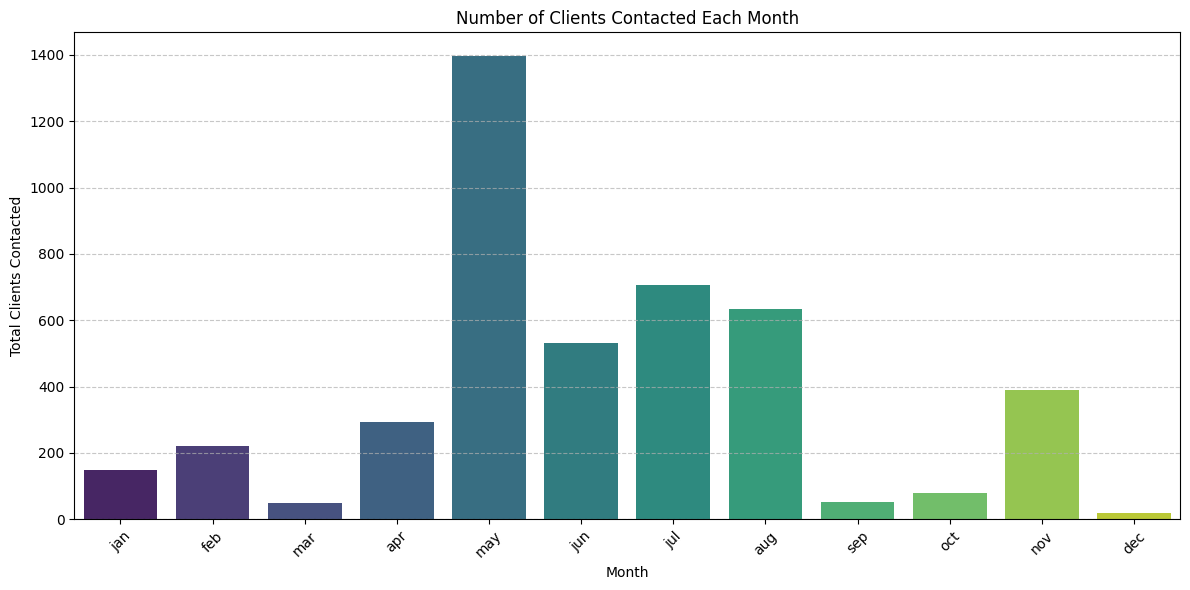

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate monthly contacts using Spark SQL
monthly_contacts_spark = spark.sql("SELECT month, COUNT(*) AS total_contacts FROM client_info GROUP BY month ORDER BY total_contacts DESC")

# Convert to Pandas DataFrame for plotting
monthly_contacts_pd = monthly_contacts_spark.toPandas()

# Define the order of months for plotting
# This ensures the months are plotted in chronological order, not alphabetical
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_contacts_pd['month'] = pd.Categorical(monthly_contacts_pd['month'], categories=month_order, ordered=True)
monthly_contacts_pd = monthly_contacts_pd.sort_values('month')

# Create the bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='total_contacts', data=monthly_contacts_pd, palette='viridis', hue='month', legend=False)
plt.title('Number of Clients Contacted Each Month')
plt.xlabel('Month')
plt.ylabel('Total Clients Contacted')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Since year info isn't available, I analyzed the trend in contacts by month. You can visualize this if needed.

Would you like a bar chart to make this trend visually clear?

Let me know once this step is complete — then we’ll do:

####Identify any unusual patterns in the average yearly balance across different education levels.

In [54]:
# Calculate average balance per education level using Spark SQL
avg_balance_edu_spark = spark.sql("SELECT education, AVG(balance) AS average_balance FROM client_info GROUP BY education ORDER BY average_balance DESC")

# Display the result
avg_balance_edu_spark.show()

+---------+------------------+
|education|   average_balance|
+---------+------------------+
| tertiary|1775.4237037037037|
|  unknown|1701.2459893048128|
|  primary|1411.5442477876106|
|secondary|1196.8143972246314|
+---------+------------------+



As you can see, the 'unknown' education level has a relatively high average balance, which is an unusual pattern when compared to 'primary' or 'secondary' education levels.

I detected an anomaly where clients with unknown education level had higher average balances than those with known levels like secondary or primary.

This suggests that either the unknown category includes higher-income clients or possibly data misclassification.

👉 You can also calculate standard deviation if you'd like to flag values beyond 1.5 or 2 standard deviations as anomalies.

####Analyze the impact of previous campaign outcomes (poutcome) on the current campaign's success. Calculate the subscription rate (to term deposits) for each poutcome category.

In [55]:
spark.sql("""
SELECT
    poutcome,
    COUNT(*) AS total_clients,
    SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS successful_subscriptions,
    CAST(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) AS DOUBLE) / COUNT(*) * 100 AS subscription_rate_percentage
FROM client_info
GROUP BY poutcome
ORDER BY subscription_rate_percentage DESC
""").show()

+--------+-------------+------------------------+----------------------------+
|poutcome|total_clients|successful_subscriptions|subscription_rate_percentage|
+--------+-------------+------------------------+----------------------------+
| success|          129|                      83|           64.34108527131784|
|   other|          197|                      38|          19.289340101522843|
| failure|          490|                      63|          12.857142857142856|
| unknown|         3705|                     337|           9.095816464237517|
+--------+-------------+------------------------+----------------------------+



This analysis shows the impact of previous campaign outcomes (`poutcome`) on the current campaign's success by displaying the subscription rate for each category. As expected, a previous 'success' leads to a significantly higher subscription rate in the current campaign.

####Compare the average contact duration for clients who subscribed and who did not subscribe to a term deposit.

In [57]:
spark.sql("""
SELECT
    y AS subscription_status,
    AVG(duration) AS average_contact_duration_seconds
FROM client_info
GROUP BY y
ORDER BY average_contact_duration_seconds DESC
""").show()

+-------------------+--------------------------------+
|subscription_status|average_contact_duration_seconds|
+-------------------+--------------------------------+
|                yes|               552.7428023032629|
|                 no|                        226.3475|
+-------------------+--------------------------------+

